Grupo 14: Claudia González y Sara Morillo

# Práctica 1 - Aprendizaje Automático
## 1. EDA y modelado 
Analizaremos: tamaño del conjunto de datos, las columnas que tiene, el tipo de datos, variables categóricas y numéricas, la cardinalidad de las categóricas y si esta es alta, si existen variables con valores faltantes y en qué proporción, si existen columnas con valores constantes o identificadores y si existe un problema de balanceo para la variable objetivo.

In [1]:
import pandas as pd
import numpy as np

In [2]:
SEED = 100499078
TARGET = "deposit"

In [3]:
ruta=r"C:\Users\saram\OneDrive\Documentos\Universidad\Cuarto\Segundo cuatri\Aprendizaje Automático\Práctica 1 - AA\ALL_bank\bank_78.pkl"
#ruta=r"C:\Users\claug\OneDrive\Escritorio\Uni\4 de carrera\aprendizaje automático\Practica1AA\bank_ALL\bank_78.pkl"

In [4]:
df = pd.read_pickle(ruta)

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 1.1. Tamaño del conjunto de datos

In [6]:
print("Tamaño", df.shape) 
# 1100 filas x 17 columnas

Tamaño (11000, 17)


## 1.2. Columnas

In [7]:
print("\nColumnas:")
print(df.columns.tolist())


Columnas:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


## 1.3. Tipo de dato de las columnas

In [8]:
print("\nTipos de datos:")
display(df.dtypes.to_frame("dtype"))


Tipos de datos:


,dtype
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


## 1.4. Diferenciamos variables categóricas y numéricas (variables X)

In [9]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Variable objetivo --> la quitamos
if TARGET in categorical_cols:
    categorical_cols.remove(TARGET)
if TARGET in numeric_cols:
    numeric_cols.remove(TARGET)
    
print("\nCategóricas:", categorical_cols)
print("\nNuméricas:", numeric_cols)


Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


## 1.5. Cardinalidad de categorías

In [10]:
# Cuántos valores distintos tiene cada variable categórica

cardinality = pd.DataFrame({"n_unique": df[categorical_cols].nunique(dropna=False)}).sort_values("n_unique", ascending=False)
cardinality["alta_cardinalidad_>10"] = cardinality["n_unique"] > 10
display(cardinality)

,n_unique,alta_cardinalidad_>10
job,13,True
month,12,True
marital,4,False
poutcome,4,False
education,4,False
contact,3,False
default,2,False
housing,2,False
loan,2,False


La mayoría de variables no superan los 10 valores distintos. No obstante, "job" y "month" sí, lo que implica que tendremos que tenerlas en cuenta en el preprocesado de datos. Por ejemplo, si luego hacemos one-hot encoding una variable con 13 valores genera muchas más columnas que una con 4. 


## 1.6. Variables con valores faltantes

In [11]:
missing = pd.DataFrame({"n_missing": df.isna().sum(), "pct_missing": df.isna().mean() * 100}).sort_values("n_missing", ascending=False)
display(missing[missing["n_missing"]>10])

,n_missing,pct_missing
marital,295,2.681818
job,123,1.118182


Vemos valores faltantes en "marital" y "job"; sin embargo, el porcentaje es relativamente bajo. Aun así, esto lo trataremos en el preprocesado quizá mediante una estrategia de imputación dentro del pipeline. 

## 1.7. Columnas con valores constantes e ID

In [12]:
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]

print("Número de columnas constantes:", len(constant_cols))
print("Columnas constantes:", constant_cols)

Número de columnas constantes: 0
Columnas constantes: []


In [13]:
# Buscaremos columnas donde el número de valores únicos sea igual al número de filas

possible_id_cols = [col for col in df.columns if df[col].nunique(dropna=False) == len(df)]
print("\nNúmero de posible columnas ID:", len(possible_id_cols))
print("\nPosible columnas ID:", possible_id_cols)


Número de posible columnas ID: 0

Posible columnas ID: []


No hay columnas constantes ni variables que parezcan ser identificadores únicos. Por tanto, no parece haber columnas triviales o de identificación directa que tengamos que eliminar por este motivo.

## 1.8. Variable objetivo

In [14]:
print(df[TARGET].value_counts())
print("\nPorcentajes:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

deposit
no     5780
yes    5220
Name: count, dtype: int64

Porcentajes:
deposit
no     52.55
yes    47.45
Name: proportion, dtype: float64


### ¿Existe problema de desbalanceo?
La variable objetivo presenta una distribución relativamente equilibrada entre clases (52.55 vs 47.75), por lo que **no parece existir un problema importante de desbalanceo.**

## 1.9. Análisis particular de `pdays`
La variable `pdays` requiere un análisis específico dentro del EDA, ya que el valor `-1` no representa una cantidad real de días, sino que indica que el cliente no había sido contactado previamente o que no se conoce dicha información. Por tanto, no es adecuado tratar este valor como si fuese un valor numérico normal.

Con el fin de representar mejor la información de esta variable, planteamos una transformación en dos pasos:
1. Construiremos una variable binaria que indique si el cliente había sido contactado previamente o no.
2. Generaremos una versión discretizada de `pdays`, agrupando los valores positivos en intervalos, para así simplificar su interpretación y facilitar su uso posterior en el modelado.

count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Frecuencia de pdays = -1:
8203

Porcentaje de pdays = -1:
74.57 %


<Axes: ylabel='Frequency'>

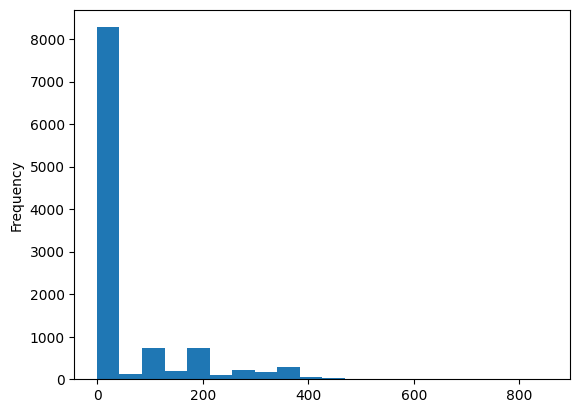

In [15]:
# Distribución inicial de pdays
print(df["pdays"].describe())

print("\nFrecuencia de pdays = -1:")
print((df["pdays"] == -1).sum())

print("\nPorcentaje de pdays = -1:")
print(round((df["pdays"] == -1).mean() * 100, 2), "%")

df['pdays'].plot.hist(bins=20)

La variable `pdays` presenta una distribución muy particular, ya que el valor `-1` aparece en 8203 observaciones, lo que supone un 74.57% del total. Además, tanto el primer cuartil como la mediana toman el valor `-1`, lo que confirma que este código domina la distribución. Esto nos indica que `pdays` no debe tratarse como una variable numérica ordinaria, sino como una variable con un valor especial que representa que no ha habido contacto previo o valor desconocido. 
Por ello, resulta razonable transformarla en variables más interpretables, como una variable binaria de contacto previo y una versión discretizada por intervalos.

In [16]:
# Variable binaria: indica si hubo o no contacto previo

def play_transforms(x):
    if x == -1:
        return 0
    else:
        return 1
        
df['wascontacted'] = df['pdays'].map(play_transforms)

In [17]:
# Variable agrupada a partir de pdays

def bin_pdays(x):
    if x == -1:
        return "no_contacto"
    elif x < 100:
        return "0_99"
    elif x < 200:
        return "100_199"
    elif x < 400:
        return "200_399"
    else:
        return "400_plus"

df["pdays_binned"] = df["pdays"].map(bin_pdays)

# Mostramos un ejemplo de varios grupos para ver que la agrupación la hemos hecho bien

display(df[["pdays", "wascontacted", "pdays_binned"]].head())
display(df.loc[(df["pdays"] >= 0) & (df["pdays"] < 100), ["pdays", "wascontacted", "pdays_binned"]].head())
display(df.loc[(df["pdays"] >= 100) & (df["pdays"] < 200), ["pdays", "wascontacted", "pdays_binned"]].head())

display(df["pdays_binned"].value_counts(dropna=False))

,pdays,wascontacted,pdays_binned
0,-1,0,no_contacto
1,-1,0,no_contacto
2,-1,0,no_contacto
3,-1,0,no_contacto
4,-1,0,no_contacto


,pdays,wascontacted,pdays_binned
891,91,1,0_99
994,27,1,0_99
1039,34,1,0_99
1043,10,1,0_99
1062,99,1,0_99


,pdays,wascontacted,pdays_binned
890,166,1,100_199
899,147,1,100_199
933,170,1,100_199
951,150,1,100_199
952,171,1,100_199


pdays_binned
no_contacto    8203
100_199        1058
200_399         871
0_99            735
400_plus        133
Name: count, dtype: int64

A parte de las conclusiones que habíamos mencionado antes observamos que, entre los clientes contactados previamente, la distribución por intervalos muestra que los rangos `100_199` y `200_399` son los más frecuentes, mientras que `400_plus` aparece en un número mucho más reducido de casos. Así, esta es una categoría minoritaria lo que nos podría aportar menos estabilidad en algunos modelos. 

<Axes: xlabel='wascontacted'>

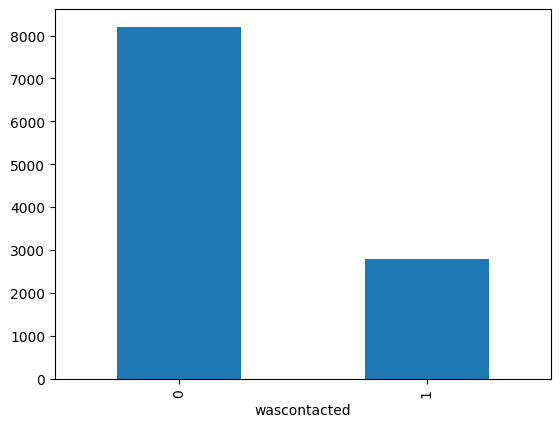

In [18]:
df["wascontacted"].value_counts().plot.bar()

### Decisión de preprocesado de `pdays`
Tras el análisis realizado, concluimos que la variable `pdays` no debe tratarse como una variable numérica convencional, ya que el valor `-1` representa ausencia de contacto previo o valor desconocido, y no una cantidad real de días. Por ello, optamos por transformar esta variable en dos nuevas representaciones más informativas: una variable binaria (`wascontacted`) que indica si el cliente había sido contactado previamente, y una variable categórica agrupada (`pdays_binned`) que discretiza los valores positivos en intervalos. 
Luego, en la fase de preparación de datos para el entrenamiento, eliminaremos la variable original `pdays` del conjunto de predictores para evitar interpretaciones erróneas durante el modelado.

# 2. Decisión de evaluación

## 2.1. Evaluación outer tipo Holdout

Como se indica en el enunciado, separaremos el dataset en un conjunto de **train** (2/3) y un conjunto de **test** (1/3), siguiendo una estrategia de evaluación **tipo holdout**. Esta partición se realizará de forma **estratificada** respecto a la variable objetivo, con el fin de mantener aproximadamente la misma proporción de clases en ambas particiones.

De este modo, el **conjunto de test** quedará reservado desde este momento y no se utilizará durante el proceso de análisis, comparación de alternativas, selección de variables ni ajuste de hiperparámetros. Su uso quedará limitado a la evaluación final, una vez se haya decidido la mejor estrategia de modelado.

## 2.2. Métrica de evaluación

Utilizaremos como métrica principal la **accuracy**, ya que, según el análisis previo de la variable objetivo, las clases presentan una distribución relativamente equilibrada.

Recordemos que la **accuracy** mide la proporción de observaciones correctamente clasificadas sobre el total. En este caso, al no existir un desbalanceo fuerte entre clases, esta métrica resulta adecuada para reflejar de forma razonable el desempeño global del modelo.

## 2.3. Evaluación inner

La evaluación interna la realizaremos únicamente sobre el conjunto de entrenamiento mediante **validación cruzada estratificada de 5 particiones**. Esta decisión se justifica porque, durante el desarrollo de la práctica, necesitaremos comparar distintas alternativas utilizando solamente el conjunto de entrenamiento, sin usar el conjunto de test. En este contexto, la validación cruzada nos permite obtener una estimación más robusta y estable del rendimiento que una única partición interna de train.

En concreto, el conjunto de entrenamiento se dividirá en varias particiones y el proceso de entrenamiento-validación se repetirá varias veces, utilizando en cada iteración una partición distinta como validación y las restantes como entrenamiento. De este modo, todas las observaciones del conjunto train participan en la evaluación, lo que reduce la dependencia de una única partición y hace más fiable la comparación entre alternativas.

Además, el hecho de que la validación cruzada sea **estratificada** garantiza que en cada fold se mantenga aproximadamente la misma proporción de clases que en el conjunto de entrenamiento completo. Esto resulta especialmente importante en problemas de clasificación, ya que evita particiones internas poco representativas.

Por último, la elección de **5 folds** responde al equilibrio entre dos aspectos: por un lado, obtener una estimación suficientemente estable del rendimiento y, por otro, no incrementar excesivamente el coste computacional, dado que este procedimiento se aplicará repetidamente al comparar preprocesados, modelos e hiperparámetros.


# 3. Métodos básicos: KNN y Trees

## 3.1. Preparación del conjunto de variables para el modelado
Antes de comparar los métodos KNN y árboles de decisión, es necesario fijar el conjunto de variables que se utilizarán en el modelado y cómo se tratará cada una de ellas en el preprocesado. A partir del análisis, hemos decidido no utilizar la variable `pdays`en su forma orginal. En su lugar, esa información la recogeremos mediante dos variables: `wascontacted`, que indica si el cliente ha sido contactado previamente, y `pdays_binned`, que agrupa en intervalos los casos en los que sí hubo contacto previo. 

In [19]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_binned']
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'wascontacted']


## 3.2. Selección del método de escalado para KNN
Ahora, antes de evaluar y comparar los métodos considerados en esta sección, es necesario decidir qué **estrategia de escalado** es la más adecuada para KNN. Esto es realmente clave ya que, como el funcionamiento de KNN se basa en distancias, la escala de las variables numéricas puede influir de forma directa en el resultado. En concreto, compararemos los 3 métodos de escalado habituales:
1. `MinMaxScaler`: transforma cada variable para que tome valores dentro de un intervalo fijo.
2. `StandardScaler`: centra y escala las variables en función de su media y desviación típica.
3. `RobustScaler`: utiliza medidas robustas frente a valores extremos, como la mediana y el rango intercuartílico.

Para dicha comparación, se entrenerá un modelo KNN con la misma configuración en los 3 casos, variando únicamente el método de escalado aplicado a las variables numéricas. Utilizaremos la validación cruzada sobre el conjunto de entrenamiento, usando la métrica de accuracy. Así, el escalado con mejor rendimiento medio será el que se utilice a patir de este punto en todos los experimentos con KNN. 

### Separación X e Y

In [20]:
# Convertimos None a NaN en todas las columnas categóricas
for col in cat_cols:
    df[col] = df[col].replace({None: np.nan})
    
X = df.drop("deposit", axis=1)
y = df["deposit"]

### Partición de los datos

Para decidir sobre el método de escalado hemos realizado antes una partición holdout del conjunto de datos, separándolo en entrenamiento y test en proporción 2/3–1/3, de forma estratificada respecto a la variable objetivo.

El objetivo de esta partición es disponer de un conjunto de datos independiente que no intervenga en el entrenamiento del modelo, permitiendo así una evaluación final objetiva de su rendimiento.

Como resultado, hemos obtenido:
- Conjunto de entrenamiento: 7333 muestras con 17 variables.
- Conjunto de test: 3667 muestras con 17 variables.

Esta separación garantiza que el modelo se entrena adecuadamente y que su rendimiento puede evaluarse de forma realista sobre datos no vistos previamente.

In [21]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=1/3,         
    random_state=SEED, 
    stratify=y             
)

# Evaluación inner: validación cruzada estratificada
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("¡Partición realizada con éxito!")
print(f"Datos para entrenar (X_train): {X_train.shape}")
print(f"Datos ocultos para el test final (X_test): {X_test.shape}")

¡Partición realizada con éxito!
Datos para entrenar (X_train): (7333, 18)
Datos ocultos para el test final (X_test): (3667, 18)


In [22]:
# Comprobamos que no falta ninguna columna
print("Columnas categóricas:")
print(cat_cols)

print("\nColumnas numéricas:")
print(num_cols)

print("\n¿Falta alguna columna en X_train?")
faltan = [col for col in cat_cols + num_cols if col not in X_train.columns]
print(faltan)

Columnas categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_binned']

Columnas numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'wascontacted']

¿Falta alguna columna en X_train?
[]


### Comparación de escaladores

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

resultados_escalado = []

for nombre_scaler, scaler in scalers.items():
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', scaler, num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )
    
    pipe_knn = Pipeline([
        ('preprocessing', preprocessor),
        ('model', KNeighborsClassifier())
    ])
    
    scores = cross_val_score(
        pipe_knn,
        X_train,
        y_train,
        cv=cv_inner,
        scoring='accuracy',
        n_jobs=-1
    )
    
    resultados_escalado.append({
        'Escalado': nombre_scaler,
        'Accuracy media CV': scores.mean(),
        'Desv. típica CV': scores.std()
    })

df_escalado_knn = pd.DataFrame(resultados_escalado).sort_values(
    by='Accuracy media CV',
    ascending=False
).reset_index(drop=True)

display(df_escalado_knn)

mejor_scalado_nombre = df_escalado_knn.loc[0, 'Escalado']
print(f"El mejor método de escalado para KNN es: {mejor_scalado_nombre}")

,Escalado,Accuracy media CV,Desv. típica CV
0,StandardScaler,0.809357,0.009100
1,RobustScaler,0.802128,0.004904
2,MinMaxScaler,0.737078,0.009315


El mejor método de escalado para KNN es: StandardScaler


Los resultados obtenidos nos muestran que StandardScaler tiene la mayor accuracy media en validación cruzada. Además, la desviación típica entre folds es reducida en los 3 casos, lo que nos indica que el comportamiento de los modelos es estable. 
Como consecuencia, seleccionamos **StandardScaler** como método de escalado para KNN en los siguientes experimentos. 

## 3.3. Evaluación con hiperparámetros por omisión
### KNN
Una vez hemos seleccionado el método de escalado más adecuado para KNN, evaluaremos este modelo con sus hiperparámetros por omisión. Para ello, se construye una pipeline completa con el preprocesado de las variables y el clasificador. 
En concreto, las **variables numéricas** se escalan mediante **StandardScaler**, mientras que las **variables categóricas** se transforman mediante **OneHotEncoder**. La evaluación se realizará sobre el conjunto de entrenamiento usando validación cruzada estratificada, y además se medirá el tiempo de entrenamiento.

In [24]:
# Pipeline de KNN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import time

preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

pipe_knn_default = Pipeline([
    ('preprocessing', preprocessor_knn),
    ('model', KNeighborsClassifier())
])

pipe_knn_default

# Evaluación con validación cruzada
import time
from sklearn.model_selection import cross_val_score

# KNN default
inicio_knn = time.time()
scores_knn_default = cross_val_score(
    pipe_knn_default,
    X_train,
    y_train,
    cv=cv_inner,
    scoring='accuracy',
    n_jobs=-1
)
fin_knn = time.time()
tiempo_knn_default = fin_knn - inicio_knn

print("Accuracy por fold (KNN por defecto):", scores_knn_default)
print(f"Accuracy media CV: {scores_knn_default.mean():.4f}")
print(f"Desviación típica CV: {scores_knn_default.std():.4f}")
print(f"Tiempo de entrenamiento y evaluación CV: {tiempo_knn_default:.4f} segundos")


Accuracy por fold (KNN por defecto): [0.7941377  0.8070893  0.81526926 0.80900409 0.8212824 ]
Accuracy media CV: 0.8094
Desviación típica CV: 0.0091
Tiempo de entrenamiento y evaluación CV: 0.3699 segundos


El modelo obtiene una accuracy media de 0.8094, con una desviación típica de 0.0091 entre folds, lo que indica un **comportamiento bastante estable**. En cuanto al coste computacional, el tiempo total de entrenamiento y evaluación mediante validación cruzada ha sido de 7.705 segundos. Por tanto, KNN con hiperparámetros por defecto es una primera referencia sólida para este problema, que más adelante compararemos con el árbol de decisión y con las versiones ajustadas mediante optimización de hiperparámetros.

### Árbol de decisión
A continuación, evaluaremos un árbol de decisión con sus hiperparámetros por omisión. En este caso, no es necesario aplicar escalado a las variables numéricas, ya que los árboles no se basan en distancias. Sin embargo, las variables categóricas sí deben transformarse mediante codificación para que el modelo pueda utilizarlas.

In [25]:
# Pipeline de Tree
from sklearn.tree import DecisionTreeClassifier

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

pipe_tree_default = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

# Evaluación
inicio_tree = time.time()
scores_tree_default = cross_val_score(
    pipe_tree_default,
    X_train,
    y_train,
    cv=cv_inner,
    scoring='accuracy',
    n_jobs=-1
)
fin_tree = time.time()
tiempo_tree_default = fin_tree - inicio_tree

print("Accuracy por fold (Tree por defecto):", scores_tree_default)
print(f"Accuracy media CV: {scores_tree_default.mean():.4f}")
print(f"Desviación típica CV: {scores_tree_default.std():.4f}")
print(f"Tiempo de entrenamiento y evaluación CV: {tiempo_tree_default:.4f} segundos")

Accuracy por fold (Tree por defecto): [0.78800273 0.799591   0.79277437 0.77830832 0.7851296 ]
Accuracy media CV: 0.7888
Desviación típica CV: 0.0072
Tiempo de entrenamiento y evaluación CV: 0.3750 segundos


### Comparación

In [26]:
resultados_modelos_default = pd.DataFrame([
    {
        'Modelo': 'KNN (default)',
        'Accuracy media CV': scores_knn_default.mean(),
        'Desv. típica CV': scores_knn_default.std(),
        'Tiempo (s)': tiempo_knn_default
    },
    {
        'Modelo': 'Decision Tree (default)',
        'Accuracy media CV': scores_tree_default.mean(),
        'Desv. típica CV': scores_tree_default.std(),
        'Tiempo (s)': tiempo_tree_default
    }
])

display(resultados_modelos_default.round(4))

,Modelo,Accuracy media CV,Desv. típica CV,Tiempo (s)
0,KNN (default),0.8094,0.0091,0.3699
1,Decision Tree (default),0.7888,0.0072,0.3750


Los resultados muestran que KNN obtiene un mejor rendimiento predictivo, con una accuracy media de 0.8094, frente a 0.7888 del árbol de decisión. Por tanto, en esta primera comparación, KNN se comporta mejor que el árbol. En cuanto al coste computacional, el árbol de decisión resulta más rápido (0.3852 s) que KNN (0.9440 s), aunque ambos tiempos son reducidos. Por ello, puede decirse que KNN ofrece una mejora en rendimiento a cambio de un coste computacional algo mayor, pero todavía moderado. Además, la desviación típica entre folds es baja en ambos modelos, lo que indica que los resultados son estables y consistentes entre particiones.

## 3.4. Árboles poco profundos
Para **comprender cómo el modelo toma sus decisiones** basándose en los datos del cliente vamos a entrenar un Árbol de decisión limitando su profundidad máxima a 3 niveles. Así, el objetivo de este punto no es obtener el mejor rendimiento posible, sino identificar qué variables aparecen en las primeras divisiones y qué tipo de reglas simples permiten discriminar entre clientes con mayor o menos probabilidad de suscribir el depósito. 

Entrenando y dibujando árbol poco profundo (max_depth=3)...



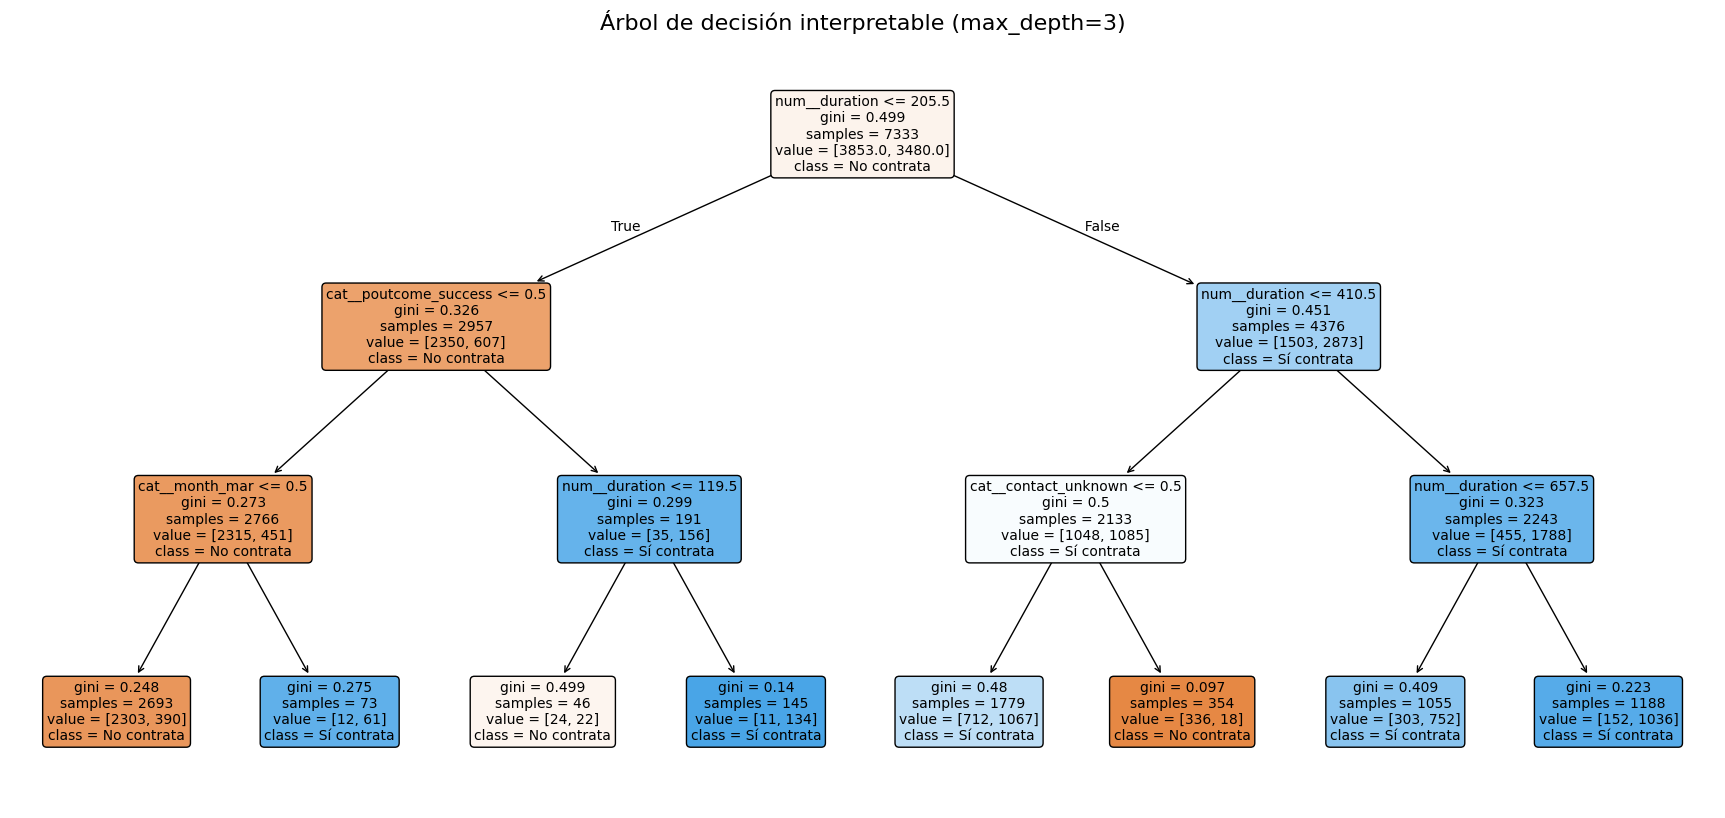

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

print("Entrenando y dibujando árbol poco profundo (max_depth=3)...\n")
# Preprocesador
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', SkPipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', SkPipeline([
            ('imputer', SimpleImputer(strategy='most_frequent', missing_values=np.nan)),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

# 1. Creamos la pipeline con el árbol limitado
pipe_tree_shallow = Pipeline([
    ('preprocessing', preprocessor_tree),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

# 2. Entrenamos el modelo directamente (sin validación cruzada, solo para dibujar)
pipe_tree_shallow.fit(X_train, y_train)

# 3. Extraemos los nombres de las columnas que salen del preprocesador
nombres_variables = pipe_tree_shallow.named_steps['preprocessing'].get_feature_names_out()

# 4. Dibujamos el árbol
plt.figure(figsize=(22, 10))
plot_tree(
    pipe_tree_shallow.named_steps['model'],
    feature_names=nombres_variables,
    class_names=['No contrata', 'Sí contrata'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de decisión interpretable (max_depth=3)", fontsize=16)
plt.show()

### Conclusiones
El árbol poco profundo nos permite observar de manera intepretable qué variables intervienen en las primeras decisiones del modelo. En particular, las divisiones más cercanas a la raíz indican qué atributos son más relevantes para separar clientes con distinta probabilidad de suscripción. 

En el nodo raíz, tenemos **duration** como variable más discriminativa, esto es la duración de la última llamada telefónica en segundos. Al principio, las clases están muy mezcladas (Gini de 0.499) y nuestro árbol usa esta variables para determinar la primera gran se paración: más de 205.5 seg (la mayoría, 4376 clientes) o menos (2957 clientes). Si la llamada fue corta, el cliente probablemente no se interesó; mientras que si fue larga, es muy probable que se consiguiera enganchar al cliente. 

En el segundo nivel, centrándonos en los clientes con llamadas cortas, el **resultado de campañas anteriores** es clave: haber tenido éxito previo aumenta significativamente la probabilidad de contratación incluso con llamadas breves. Para llamadas de duración media (205.5 < duration < 410.5), el **medio de contacto** es un buen discriminador: cuando no se conoce el canal, la probabilidad de contratación cae. 

En general, el árbol muestra que el proceso de decisión en est eproblema puede resumirse en pocas reglas simples e interpretables. 

## 3.5. Ajuste de hiperparámetros

A continuación, vamos a buscar la configuración óptima para nuestros dos modelos.
- Para **KNN**, buscaremos el número óptimo de vecinos.
- Para el **Árbol**, buscaremos la profundidad máxima ideal.

Mediremos los tiempos de este proceso y visualizaremos mediante gráficas cómo afecta la variación de estos parámetros al rendimiento del modelo.

Iniciando Búsqueda de Hiperparámetros (HPO)... Esto puede tardar un poco.

Mejor KNN encontrado: {'model__n_neighbors': 7}
Accuracy del mejor KNN: 0.8136 (Tiempo de búsqueda: 4.10 s)

Mejor Árbol encontrado: {'model__max_depth': 11}
Accuracy del mejor Árbol: 0.8163 (Tiempo de búsqueda: 3.13 s)



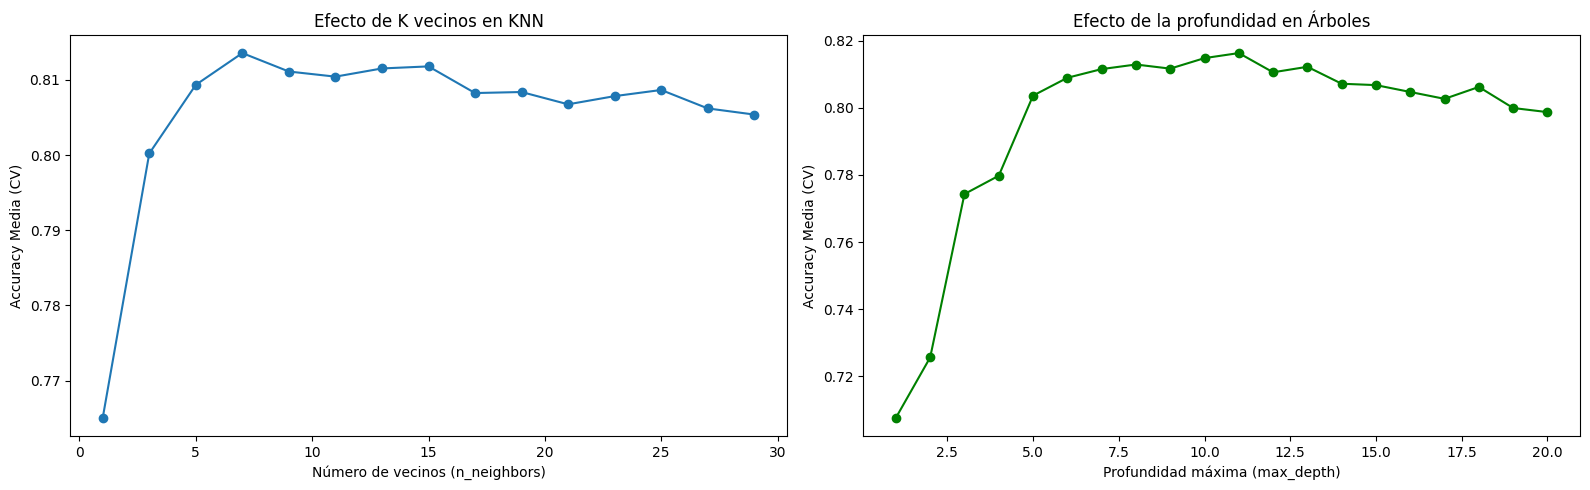

In [28]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import time
import matplotlib.pyplot as plt

print("Iniciando Búsqueda de Hiperparámetros (HPO)... Esto puede tardar un poco.\n")

param_grid_knn = {'model__n_neighbors': range(1, 31, 2)} # # Definimos los valores de n_neighbors que queremos explorar (impares del 1 al 29)

# Medimos el tiempo de búsqueda para KNN
inicio_hpo_knn = time.time()

# GridSearchCV prueba cada valor del grid con validación cruzada y se queda con el mejor
grid_knn = GridSearchCV(pipe_knn_default, param_grid_knn, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train, y_train)

tiempo_hpo_knn = time.time() - inicio_hpo_knn

# Definimos los valores de max_depth que queremos explorar (del 1 al 20)
param_grid_tree = {'model__max_depth': range(1, 21)} # Prueba profundidades del 1 al 20

# Medimos el tiempo de búsqueda para el árbol
inicio_hpo_tree = time.time()

grid_tree = GridSearchCV(pipe_tree_default, param_grid_tree, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_train, y_train)

tiempo_hpo_tree = time.time() - inicio_hpo_tree

# Mostramos los mejores hiperparámetros encontrados y su accuracy
print(f"Mejor KNN encontrado: {grid_knn.best_params_}")
print(f"Accuracy del mejor KNN: {grid_knn.best_score_:.4f} (Tiempo de búsqueda: {tiempo_hpo_knn:.2f} s)\n")

print(f"Mejor Árbol encontrado: {grid_tree.best_params_}")
print(f"Accuracy del mejor Árbol: {grid_tree.best_score_:.4f} (Tiempo de búsqueda: {tiempo_hpo_tree:.2f} s)\n")

# Creamos una figura con dos subplots lado a lado, uno para KNN y otro para el árbol
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Extraemos los resultados del GridSearch de KNN en un DataFrame para poder visualizarlos
resultados_knn = pd.DataFrame(grid_knn.cv_results_)

# Representamos la accuracy media en CV para cada valor de n_neighbors
# Así vemos cómo evoluciona el rendimiento al aumentar el número de vecinos
axes[0].plot(resultados_knn['param_model__n_neighbors'], resultados_knn['mean_test_score'], marker='o')
axes[0].set_title("Efecto de K vecinos en KNN")
axes[0].set_xlabel("Número de vecinos (n_neighbors)")
axes[0].set_ylabel("Accuracy Media (CV)")


resultados_tree = pd.DataFrame(grid_tree.cv_results_)

# Representamos la accuracy media en CV para cada valor de max_depth
# Así vemos cómo evoluciona el rendimiento al aumentar la profundidad del árbol
axes[1].plot(resultados_tree['param_model__max_depth'], resultados_tree['mean_test_score'], marker='o', color='green')
axes[1].set_title("Efecto de la profundidad en Árboles")
axes[1].set_xlabel("Profundidad máxima (max_depth)")
axes[1].set_ylabel("Accuracy Media (CV)")

plt.tight_layout()
plt.show()

### Tabla comparativa

In [29]:
# Construimos una tabla que agrupa los 4 modelos (default y HPO) para comparar
# su rendimiento y coste computacional de forma clara

resultados_completos = pd.DataFrame([
    {
        'Modelo': 'KNN (default)',
        'Accuracy media CV': scores_knn_default.mean(),
        'Desv. típica CV': scores_knn_default.std(),
        'Tiempo (s)': tiempo_knn_default
    },
    {
        'Modelo': 'Decision Tree (default)',
        'Accuracy media CV': scores_tree_default.mean(),
        'Desv. típica CV': scores_tree_default.std(),
        'Tiempo (s)': tiempo_tree_default
    },
    {
        'Modelo': 'KNN (HPO)',
        'Accuracy media CV': grid_knn.best_score_,
        # Extraemos la desv. típica del fold correspondiente al mejor resultado
        'Desv. típica CV': resultados_knn.loc[grid_knn.best_index_, 'std_test_score'],
        'Tiempo (s)': tiempo_hpo_knn
    },
    {
        'Modelo': 'Decision Tree (HPO)',
        'Accuracy media CV': grid_tree.best_score_,
        # Extraemos la desv. típica del fold correspondiente al mejor resultado
        'Desv. típica CV': resultados_tree.loc[grid_tree.best_index_, 'std_test_score'],
        'Tiempo (s)': tiempo_hpo_tree
    }
])

display(resultados_completos.round(4))

,Modelo,Accuracy media CV,Desv. típica CV,Tiempo (s)
0,KNN (default),0.8094,0.0091,0.3699
1,Decision Tree (default),0.7888,0.0072,0.3750
2,KNN (HPO),0.8136,0.0060,4.1010
3,Decision Tree (HPO),0.8163,0.0052,3.1332


### Análisis de los resultados

En primer lugar, el ajuste de hiperparámetros mejora el rendimiento en ambos modelos, aunque no de manera exagerada.

- En **KNN**: Con k=1 el modelo sobreajusta claramente (accuracy ~0.77), ya que memoriza el conjunto de entrenamiento sin generalizar. A medida que aumentamos el número de vecinos, la accuracy sube hasta alcanzar **su pico en k=7** (accuracy 0.8136). A partir de ahí, añadir más vecinos produce una caída gradual del rendimiento, ya que el modelo se vuelve demasiado rígido y pierde capacidad de discriminación local.
- En el **Árbol de Decisión**: Con profundidades muy bajas (1-2) el modelo no es capaz de capturar la complejidad del problema, obteniendo una accuracy de apenas 0.71. Al aumentar la profundidad el rendimiento mejora rápidamente, alcanzando **su máximo en max_depth=11**  (accuracy 0.8163). Por encima de ese valor la curva cae ligeramente y se vuelve inestable, lo que es señal de overfitting: el árbol empieza a memorizar el conjunto de entrenamiento en lugar de aprender patrones generalizables.

## 3.6. Conclusiones generales

### Modelos triviales
Antes de comparar los modelos, establecemos un baseline mínimo con el que comparar, mediante modelos triviales. Estos modelos no aprenden ningún patrón a partir de los datos, sino que predicen siempre siguiendo una estrategia fija. Cualquier modelo real debería supera claramente estas cifras para justificar su uso.

Para ello, consideraremos dos estrategias:
- **most_frequent**: predice siempre la clase mayoritaria, independientemente de los datos de entrada.
- **stratified**: predice aleatoriamente respetando la proporción de clases del conjunto de entrenamiento.


In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

resultados_dummy = []

for estrategia in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=estrategia, random_state=SEED)
    scores_dummy = cross_val_score(dummy, X_train, y_train, cv=cv_inner, scoring='accuracy')
    resultados_dummy.append({
        'Modelo': f'Dummy ({estrategia})',
        'Accuracy media CV': scores_dummy.mean(),
        'Desv. típica CV': scores_dummy.std()
    })

df_dummy = pd.DataFrame(resultados_dummy)
display(df_dummy.round(4))

,Modelo,Accuracy media CV,Desv. típica CV
0,Dummy (most_frequent),0.5254,0.0002
1,Dummy (stratified),0.5048,0.0028


Como cabía esperar dado el equilibrio entre clases que observamos en el EDA, ambos modelos obtienen una accuracy en torno al 50%, lo que confirma que se trata de un problema no trivial donde el aprendizaje real es necesario.

A partir de las pruebas realizadas en este punto 3, podemos extraer diferentes conclusiones:

En primer lugar, **el mejor modelo es el Decision Tree con HPO (max_depth=11)**, con una accuracy media en validación cruzada de 0.8163. Aunque la diferencia con KNN HPO (0.8136) es pequeña, el árbol tiene la vemtaja adicional de que es interpretable, como hemos visto en el árbol poco profundo.

Con respecto al **coste computacional**, con hiperparámetros por defecto, ambos modelos son muy rápidos (~0.33). El HPO incrementa el tiempo de manera notable (3.82s para KNN y 2.81s para el árbol), ya que implica entrenar y evaluar múltiples configuraciones mediante validación cruzada. Sin embargo, estos tiempos son completamente sumibles para el tamaño del conjunto de datos que nos dan.

Por otro lado, los reusltado mejoran de forma muy clara a los modelos dummy. Los modelos dummy obtienen una accuracy entre 0.5048 y 0.5254, mientras que todos los modelos reales superan el 0.78. Esto nos confirman que tanto KNN como el árbol de decisión son capaces de aprender patrones relevantes a partir de los datos.

Por último, cabe destacar que el ajuste de hiperparámetros mejora los resultados de forma moderada. La mejora de KNN es de 0.8094 a 0.8136 y del árbol 0.7888 a 0.8163. La mejora más significativa es la del árbol, que con el HPO pasa a ser el modelo más preciso y además reduce la desviación típica, indocándonos mayor estabilidad.

# 4. Métodos avanzados: Modelos lineales y SVMs
## 4.1. Modelos lineales y SVM con hiperparámetros por defecto
En este punto, evaluaremos los tres modelos de mayor complejidad que los vistos antes: la regresión logística sin regularización, con regularización L1 y las máquinas de soporte de vectores (SVM).
Al igual que en la sección anterior, seguiremos con las mismas estrategias de evaluación: validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento, usando accuracy como métrica, y midiendo los tiempos de entrenamiento. 

In [31]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import pandas as pd
import time

# Para modelos lineales y SVM sí es necesario escalar las variables numéricas,
# ya que estos métodos son sensibles a la escala (igual que KNN)
preprocessor_lineal = ColumnTransformer(
    transformers=[
        ('num', SkPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', SkPipeline([
            ('imputer', SimpleImputer(strategy='most_frequent', missing_values=np.nan)),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

# Uso de IA generativa 
# Regresión Logística sin regularización
# C=np.inf equivale a penalty=None (sin regularización)
pipe_lr = Pipeline([
    ('preprocessing', preprocessor_lineal),
    ('model', LogisticRegression(C=np.inf, max_iter=5000, random_state=SEED))
])

# Regresión Logística con regularización L1
# l1_ratio=1 equivale a penalty='l1'
pipe_lr_l1 = Pipeline([
    ('preprocessing', preprocessor_lineal),
    ('model', LogisticRegression(l1_ratio=1, solver='saga', max_iter=5000, random_state=SEED))
])

# SVM
# Por defecto usa kernel RBF, que permite capturar relaciones no lineales
pipe_svm = Pipeline([
    ('preprocessing', preprocessor_lineal),
    ('model', SVC(random_state=SEED))
])

# Evaluación de los tres modelos con validación cruzada
modelos = {
    'Logistic Regression (sin regularización)': pipe_lr,
    'Logistic Regression (L1)': pipe_lr_l1,
    'SVM (default)': pipe_svm
}

resultados_avanzados_default = []

for nombre, pipe in modelos.items():
    inicio = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='accuracy', n_jobs=-1)
    tiempo = time.time() - inicio

    resultados_avanzados_default.append({
        'Modelo': nombre,
        'Accuracy media CV': scores.mean(),
        'Desv. típica CV': scores.std(),
        'Tiempo (s)': tiempo
    })

df_avanzados_default = pd.DataFrame(resultados_avanzados_default)
display(df_avanzados_default.round(4))

,Modelo,Accuracy media CV,Desv. típica CV,Tiempo (s)
0,Logistic Regression (sin regularización),0.8261,0.0088,0.2054
1,Logistic Regression (L1),0.8254,0.0088,17.3350
2,SVM (default),0.8519,0.0083,2.5486


A diferencia de los árboles de decisión, los modelos lineales y las SVMs son sensibles a la escala de las variables, por lo que es necesario hacer el escalado a las variables numéricas. Como determinamos que `StandardScaler`es el método más adecuado para este problema, lo utilizaremos.

En primer lugar, la **regresión logística sin regularización** (`penaly=None`) sirve como modelo lineal base, sin ningún tipo de penalización sobre los coeficientes.
Por otro lado, la **regresión logística con L1** añade una penalización que puede llevar a algunos coeficientes a ser cero exactamente, lo que permite una selección implícita de variables y facilitará la posterior interpretación.
Por último, la **SVM** con configuración por defecto utiliza un kernel RBF, que le permite capturar relaciones no lineales entre variables, a diferencia de los dos modelos anteriores. 

### Análisis de los resultados
Los 3 modelos superan claramente el baseline dummy y también mejoran los resultados obtenido en la sección anterior con KNN y árboles.
La SVM es el modelo más preciso con una accuracy de 0.8530, y además presenta la desviación típica más baja, lo que nos indica que es el modelo más estable entre folds. Sin embargo, es también el más costoso computacionalmente junto con la regresión logística L1.
Las dos versiones de Regresión logística obtiene resultados muy similares entre sí, lo que nos sugiere que en esta configuración por defecto la regularización L1 apenas aporta mejora. No obstante, la L1 tiene la ventaja de que nos permite identificar qué variables son relevantes a través de sus coeficientes.
Con respecto al coste computacional, los tres modelos son más lentos que KNN y el árbol con hiperparámetros por defecto. Esto es bastante esperable ya que estos métodos son más complejos internamente, aunque los tiempos siguen siendo razonables para el tamaño del conjunto de datos.

## 4.2. Ajuste de hiperparámetros

Iniciando HPO para modelos avanzados.

Mejor LR (sin reg.): {'model__C': 0.1} → Accuracy: 0.8267 (Tiempo: 0.84 s)
Mejor LR (L1): {'model__C': 10} → Accuracy: 0.8263 (Tiempo: 23.82 s)
Mejor SVM: {'model__C': 1, 'model__gamma': 'scale'} → Accuracy: 0.8519 (Tiempo: 42.52 s)


,Modelo,Accuracy media CV,Desv. típica CV,Tiempo (s)
0,"LR (sin regularización, default)",0.8261,0.0088,0.2054
1,"LR (sin regularización, HPO)",0.8267,0.0088,0.8376
2,LR L1 (default),0.8254,0.0088,17.3350
3,LR L1 (HPO),0.8263,0.0091,23.8199
4,SVM (default),0.8519,0.0083,2.5486
5,SVM (HPO),0.8519,0.0083,42.5249


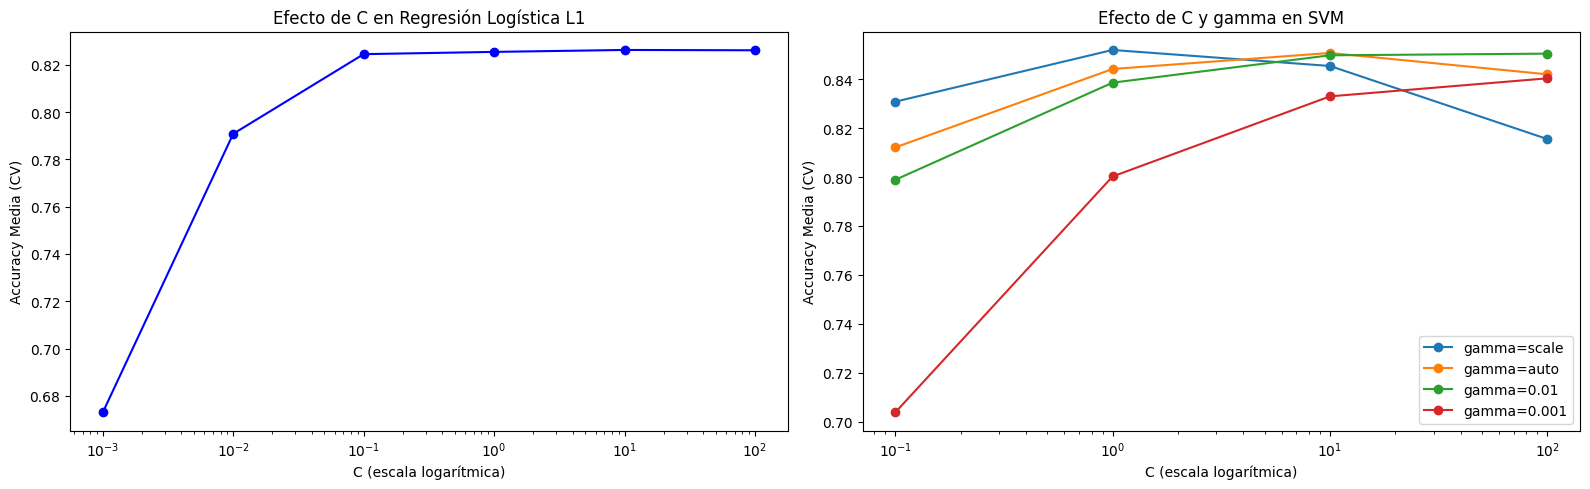

In [32]:
from sklearn.model_selection import GridSearchCV
import time
import pandas as pd
import matplotlib.pyplot as plt

print("Iniciando HPO para modelos avanzados.\n")

# HPO Regresión Logística sin regularización 
# El hiperparámetro más relevante cuando no hay regularización es el solver
# y el número máximo de iteraciones para asegurar convergencia
param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]  
}
# Nota: aunque penalty=None, exploramos C por coherencia con la pipeline,
# pero su efecto es nulo sin regularización. El parámetro realmente útil aquí
# es max_iter, que ya fijamos en 1000.

# HPO Regresión Logística L1
# C controla la intensidad de la regularización: valores bajos = más regularización
param_grid_lr_l1 = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# HPO SVM 
# C controla el margen de separación, gamma controla la influencia de cada punto
param_grid_svm = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto', 0.01, 0.001]
}

# Búsqueda para Regresión Logística sin regularización 
inicio_hpo_lr = time.time()
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train, y_train)
tiempo_hpo_lr = time.time() - inicio_hpo_lr

# Búsqueda para Regresión Logística L1 
inicio_hpo_lr_l1 = time.time()
grid_lr_l1 = GridSearchCV(pipe_lr_l1, param_grid_lr_l1, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_lr_l1.fit(X_train, y_train)
tiempo_hpo_lr_l1 = time.time() - inicio_hpo_lr_l1

# Búsqueda para SVM
inicio_hpo_svm = time.time()
grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=cv_inner, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)
tiempo_hpo_svm = time.time() - inicio_hpo_svm

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejor LR (sin reg.): {grid_lr.best_params_} → Accuracy: {grid_lr.best_score_:.4f} (Tiempo: {tiempo_hpo_lr:.2f} s)")
print(f"Mejor LR (L1): {grid_lr_l1.best_params_} → Accuracy: {grid_lr_l1.best_score_:.4f} (Tiempo: {tiempo_hpo_lr_l1:.2f} s)")
print(f"Mejor SVM: {grid_svm.best_params_} → Accuracy: {grid_svm.best_score_:.4f} (Tiempo: {tiempo_hpo_svm:.2f} s)")

# Tabla comparativa
resultados_lr = pd.DataFrame(grid_lr.cv_results_)
resultados_lr_l1 = pd.DataFrame(grid_lr_l1.cv_results_)
resultados_svm = pd.DataFrame(grid_svm.cv_results_)

df_avanzados_hpo = pd.DataFrame([
    {
        'Modelo': 'LR (sin regularización, default)',
        'Accuracy media CV': df_avanzados_default[df_avanzados_default['Modelo'] == 'Logistic Regression (sin regularización)']['Accuracy media CV'].values[0],
        'Desv. típica CV': df_avanzados_default[df_avanzados_default['Modelo'] == 'Logistic Regression (sin regularización)']['Desv. típica CV'].values[0],
        'Tiempo (s)': df_avanzados_default[df_avanzados_default['Modelo'] == 'Logistic Regression (sin regularización)']['Tiempo (s)'].values[0]
    },
    {
        'Modelo': 'LR (sin regularización, HPO)',
        'Accuracy media CV': grid_lr.best_score_,
        'Desv. típica CV': resultados_lr.loc[grid_lr.best_index_, 'std_test_score'],
        'Tiempo (s)': tiempo_hpo_lr
    },
    {
        'Modelo': 'LR L1 (default)',
        'Accuracy media CV': df_avanzados_default[df_avanzados_default['Modelo'] == 'Logistic Regression (L1)']['Accuracy media CV'].values[0],
        'Desv. típica CV': df_avanzados_default[df_avanzados_default['Modelo'] == 'Logistic Regression (L1)']['Desv. típica CV'].values[0],
        'Tiempo (s)': df_avanzados_default[df_avanzados_default['Modelo'] == 'Logistic Regression (L1)']['Tiempo (s)'].values[0]
    },
    {
        'Modelo': 'LR L1 (HPO)',
        'Accuracy media CV': grid_lr_l1.best_score_,
        'Desv. típica CV': resultados_lr_l1.loc[grid_lr_l1.best_index_, 'std_test_score'],
        'Tiempo (s)': tiempo_hpo_lr_l1
    },
    {
        'Modelo': 'SVM (default)',
        'Accuracy media CV': df_avanzados_default[df_avanzados_default['Modelo'] == 'SVM (default)']['Accuracy media CV'].values[0],
        'Desv. típica CV': df_avanzados_default[df_avanzados_default['Modelo'] == 'SVM (default)']['Desv. típica CV'].values[0],
        'Tiempo (s)': df_avanzados_default[df_avanzados_default['Modelo'] == 'SVM (default)']['Tiempo (s)'].values[0]
    },
    {
        'Modelo': 'SVM (HPO)',
        'Accuracy media CV': grid_svm.best_score_,
        'Desv. típica CV': resultados_svm.loc[grid_svm.best_index_, 'std_test_score'],
        'Tiempo (s)': tiempo_hpo_svm
    }
])

display(df_avanzados_hpo.round(4))

# Plots del efecto de C en regresión logística 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Extraemos resultados de LR L1 para visualizar el efecto de C
axes[0].plot(resultados_lr_l1['param_model__C'], resultados_lr_l1['mean_test_score'], marker='o', color='blue')
axes[0].set_xscale('log')
axes[0].set_title("Efecto de C en Regresión Logística L1")
axes[0].set_xlabel("C (escala logarítmica)")
axes[0].set_ylabel("Accuracy Media (CV)")

# Extraemos resultados de SVM para visualizar el efecto de C (agrupando por gamma)
for gamma_val in ['scale', 'auto', 0.01, 0.001]:
    subset = resultados_svm[resultados_svm['param_model__gamma'] == gamma_val]
    axes[1].plot(subset['param_model__C'], subset['mean_test_score'], marker='o', label=f'gamma={gamma_val}')
axes[1].set_xscale('log')
axes[1].set_title("Efecto de C y gamma en SVM")
axes[1].set_xlabel("C (escala logarítmica)")
axes[1].set_ylabel("Accuracy Media (CV)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Análisis de los resultados

**Regresión Logística sin regularización:**
El HPO apenas aporta mejora, ya que la accuracy pasa de 0.8319 a 0.8323 con el valor óptimo encontrado de C=0.001. Esto es esperable ya que al no haber regularización el efecto de C es muy limitado. Además, el coste computacional aumenta por una mejora mínima, lo que nos confirma que en este caso, el HPO no compensa.

**Regresión Logística L1:**
De forma similar, el HPO tampoco mejora el rendimiento aunque el valor óptimo encontrado de C es 1, que coincide prácticamente con el valor por defecto de sklearn. La curva del gráfico izquierdo muestra claramente que con valores de C muy bajos (alta regularización) el modelo sufre underfitting y la accuracy cae mucho, mientras que a partir de C=0.1 el rendimiento se estabiliza. Esto nos indica que en este problema una regularización L1 moderada-baja es suficiente y que aumentarla más no aporta mejoras.

**SVM:**
La SVM es el modelo que obtiene el mejor rendimiento global de entre todas las alternativas evaluadas, alcanzando una accuracy media en validación cruzada de 0.8519. Además, presenta una baja desviación típica (0.0083), lo que indica un comportamiento estable entre particiones. No obstante, en los resultados finales observamos que el ajuste de hiperparámetros no mejora el desempeño respecto a la configuración por defecto, ya que tanto SVM (default) como SVM (HPO) obtienen exactamente la misma accuracy media y la misma variabilidad. En cambio, el coste computacional sí aumenta de forma muy notable: el tiempo pasa de aproximadamente 2.55 s en la versión por defecto a 42.52 s en la versión ajustada.

Por tanto, aunque la SVM es el mejor modelo en esta fase, los resultados indican que el HPO no aporta una mejora real en el rendimiento final, pero sí un incremento muy importante del tiempo de cómputo. En consecuencia, consideraremos más adecuada la SVM con configuración por defecto, al ofrecer el mismo desempeño que la versión ajustada con un coste mucho menor.



## 4.3. Interpretabilidad de los modelos lineales: extraer atributos más relevantes
Como hemos dicho, una ventaja clave de los modelos lineales frente a otros métodos es su **interpretabilidad**: es posible extraer directamente qué variables son más relevantes para la predicción a partir de los coeficientes aprendidos durante el entrenamiento. Cada coeficiente indica cuánto contribuye su variable correspondiente a la decisión del modelo, y en qué dirección. Así, un coeficiente positivo aumenta la probabilidad de que el cliente contrate el depósito, mientras que uno negativo la reduce. Además, en el caso de la Regresión logística con L1, la regularización lleva a algunos coeficientes a ser 0, lo que equivale a una selección implícita de variables y hace la interpretación mucho más limpia. 

Por el contrario, la SVM no permite este tipo de interpretación directa. Como se está utilizando un kernel RBF, el modelo opera en un espacio de características transformado de alta dimensionalidad que no tiene correspondencia directa con las variables originales. 

Por ello, para analizar qué variables son más determinantes en este problema utilizaremos la **Regresión Logística con L1** y el mejor valor de C encontrado en el HPO. 

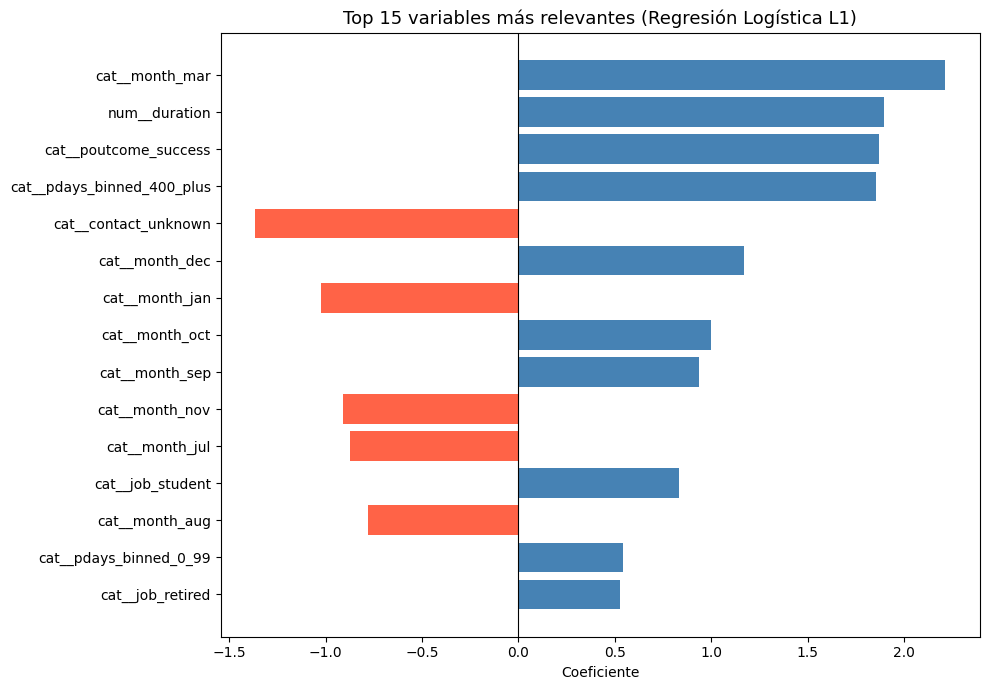

,Variable,Coeficiente
0,cat__month_mar,2.2143
1,num__duration,1.8941
2,cat__poutcome_success,1.8719
3,cat__pdays_binned_400_plus,1.8566
4,cat__contact_unknown,-1.3644
5,cat__month_dec,1.1680
6,cat__month_jan,-1.0253
7,cat__month_oct,0.9995
8,cat__month_sep,0.9371
9,cat__month_nov,-0.9109


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Entrenamos la regresión L1 con el mejor C encontrado en el HPO sobre todo X_train
pipe_lr_l1_final = Pipeline([
    ('preprocessing', preprocessor_lineal),
    ('model', LogisticRegression(l1_ratio=1, C=1, solver='saga', max_iter=5000, random_state=SEED))
])

pipe_lr_l1_final.fit(X_train, y_train)

# Extraemos los nombres de las variables tras el preprocesado
nombres_variables = pipe_lr_l1_final.named_steps['preprocessing'].get_feature_names_out()

# Extraemos los coeficientes del modelo
coeficientes = pipe_lr_l1_final.named_steps['model'].coef_[0]

# Construimos un DataFrame ordenado por valor absoluto del coeficiente
df_coef = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes
}).assign(Importancia=lambda x: x['Coeficiente'].abs()).sort_values('Importancia', ascending=False)

# Mostramos las 15 variables más relevantes
df_top = df_coef.head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colores = ['steelblue' if c > 0 else 'tomato' for c in df_top['Coeficiente']]
ax.barh(df_top['Variable'], df_top['Coeficiente'], color=colores)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title("Top 15 variables más relevantes (Regresión Logística L1)", fontsize=13)
ax.set_xlabel("Coeficiente")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(df_top[['Variable', 'Coeficiente']].reset_index(drop=True).round(4))

### Cambios en el preprocesado de datos
Durante el desarrollo de este apartado, detectamos que las variables `marital`y `job` contenían valores faltantes representados como None de Python en lugar de np.nan, lo que impedía que el SimpleImputer los detectase y los imputase correctamente y entonces el OneHotEncoder los trataba como una categoría propia. **Con la ayuda de IA generativa**, convertimos los None a np.nan antes de la partición train-test, lo que permitó a SimpleImputer imputarlos correctamente con la moda de cada variable dentro de la pipeline.

### Análisis de los atributos más relevantes
Una vez corregido el preprocesado, los resultados muestran variables con una interpretación real y coherente con el problema. Los factores que más aumentan la probabilidad de contratación son la duración de la llamada (`duration`, +1.89), el éxito en campañas anteriores (`poutcome_success`, +1.87), haber sido contactado hace más de 400 días (`pdays_binned_400_plus`, +1.72) y el mes de marzo (`month_mar`, +2.21). Por otro lado, los factores que más la reducen son el medio de contacto desconocido (`contact_unknown`, -1.36) y los meses de enero, noviembre, julio y agosto. Por otro lado, en cuanto al perfil del cliente, los estudiantes y jubilados son los más propensos a contratar. 

En general, los resultados son muy coherentes con los patrones identificados previamente en el árbol poco profundo, lo que refuerza la robustez de las conclusiones:  la duración de la llamada, el resultado de campañas anteriores, el mes de contacto y el medio de contacto son los factores más determinantes para predecir si un cliente contratará el depósito.

# 5. Resultados y modelo final
## 5.1 Selección mejor modelo (evaluación inner)
En esta sección vamos a hacer la evaluación inner con el objetivo de comparar las distintas alternativas de modelado consideradas en los apartados anteriores y seleccionar la que ofrece mejor comportamiento en el **conjunto de entrenamiento**. Para ello, utilizamos **validación cruzada estratificada**, de modo que la comparación entre modelos se realiza únicamente con los datos de entrenamiento, sin utilizar en ningún momento el conjunto de test reservado para la evaluación outer. Así, evitamos que la elección del modelo esté sesgada por el conjunto de prueba y mantenemos una estimación final más realista de su rendimiento futuro.

La métrica principal empleada para esta comparación es la **accuracy**, ya que, tal y como se justificó previamente, la variable objetivo presenta una distribución relativamente equilibrada entre clases. A partir de los resultados obtenidos, seleccionaremos la alternativa con mejor rendimiento medio y, en caso necesario, también tendremos en cuenta su estabilidad.

In [34]:
resumen_final = pd.DataFrame({
    'Modelo': [
        'KNN (default)', 'Decision Tree (default)',
        'KNN (HPO)', 'Decision Tree (HPO)',
        'LR (sin reg, default)', 'LR (sin reg, HPO)',
        'LR L1 (default)', 'LR L1 (HPO)',
        'SVM (default)', 'SVM (HPO)'
    ],
    'Accuracy media CV': [
        0.8094, 0.7888,
        0.8136, 0.8163,
        0.8261, 0.8267,
        0.8254, 0.8263,
        0.8519, 0.8519
    ],
    'Desv. típica CV': [
        0.0091, 0.0072,
        0.0060, 0.0052,
        0.0088, 0.0088,
        0.0088, 0.0091,
        0.0083, 0.0083
    ]
})

print(resumen_final.sort_values('Accuracy media CV', ascending=False).to_string(index=False))

                 Modelo  Accuracy media CV  Desv. típica CV
              SVM (HPO)             0.8519           0.0083
          SVM (default)             0.8519           0.0083
      LR (sin reg, HPO)             0.8267           0.0088
            LR L1 (HPO)             0.8263           0.0091
  LR (sin reg, default)             0.8261           0.0088
        LR L1 (default)             0.8254           0.0088
    Decision Tree (HPO)             0.8163           0.0052
              KNN (HPO)             0.8136           0.0060
          KNN (default)             0.8094           0.0091
Decision Tree (default)             0.7888           0.0072


Tras comparar las distintas alternativas mediante la evaluación inner, seleccionamos como mejor modelo SVM, ya que es el que obtiene la mayor accuracy media en validación cruzada (0.8519) y, además, presenta una baja variabilidad entre particiones (0.0083), lo que sugiere un comportamiento estable. Asimismo, evaluamos una versión de SVM con ajuste de hiperparámetros, pero los resultados muestran que este proceso no aporta ninguna mejora ni en la accuracy media ni en la desviación típica respecto a la configuración por defecto. Sin embargo, sí supone un incremento muy importante del coste computacional, pasando de aproximadamente 2.55 segundos a 42.52 segundos. 

Por tanto, optamos por la **versión por defecto del modelo SVM**, con C=1 y gamma = 'scale', ya que ofrece el mismo rendimiento que la versión ajustada pero con un coste temporal mucho menor. En consecuencia, esta será la alternativa seleccionada para llevar a cabo la evaluación outer sobre el conjunto de test.

## 5.2 Evaluación Outer
Una vez seleccionada la mejor alternativa mediante la evaluación inner, en esta sección realizamos la evaluación outer con el objetivo de estimar el rendimiento futuro del modelo sobre datos no vistos. Para ello, utilizamos el conjunto de test reservado al inicio de la práctica, que no ha intervenido ni en la comparación entre modelos ni en el ajuste de hiperparámetros. De este modo, la evaluación proporcionará una estimación más realista de cómo cabría esperar que el modelo se desempeñase en un escenario externo.

Así, esta evaluación podrá interpretarse como una aproximación a cómo se comportaría el modelo en la competición, ya que reproduce una situación en la que las predicciones se realizan sobre observaciones nuevas, no utilizadas durante el proceso de construcción del modelo.

Además de la métrica principal empleada a lo largo de la práctica, la accuracy, en esta sección incorporaremos también la matriz de confusión. Mientras que la accuracy ofrece una medida global del porcentaje de aciertos, la matriz de confusión permite analizar con mayor detalle el tipo de errores cometidos por el modelo y cómo se distribuyen sus aciertos y fallos entre las distintas clases.


Estimación del rendimiento futuro (Accuracy en Test): 0.8462


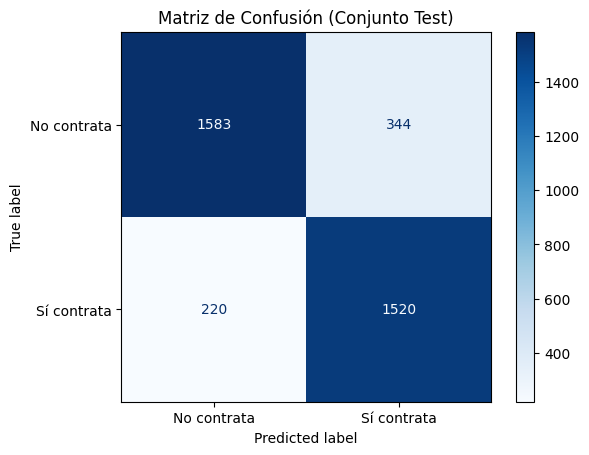

In [35]:
import joblib
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

#Definición del transformador personalizado para pdays
def transform_pdays(X):
    X_out = X.copy()
    
    X_out['wascontacted'] = X_out['pdays'].apply(lambda x: 0 if x == -1 else 1)
    
    # Discretización
    def bin_pdays(x):
        if x == -1: return "no_contacto"
        elif x < 100: return "0_99"
        elif x < 200: return "100_199"
        elif x < 400: return "200_399"
        else: return "400_plus"
        
    X_out['pdays_binned'] = X_out['pdays'].apply(bin_pdays)
    
    # Eliminamos la variable original
    X_out = X_out.drop(columns=['pdays'])
    return X_out

pdays_transformer = FunctionTransformer(transform_pdays, validate=False)

# Definición de las nuevas listas de columnas tras la transformación
num_cols_final = ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'wascontacted']
cat_cols_final = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'pdays_binned']

preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_final),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_final)
    ]
)

# 4. Pipeline Final 
pipeline_final = Pipeline([
    ('pdays_transform', pdays_transformer),
    ('preprocessing', preprocessor_final),
    ('model', SVC(C=1, gamma='scale', probability=True, random_state=SEED))
])

# 5. Evaluación Outer con Holdout
# Asumimos que X_train, X_test, y_train, y_test ya están definidos en la sección 2
pipeline_final.fit(X_train, y_train)
y_pred_test = pipeline_final.predict(X_test)

accuracy_outer = accuracy_score(y_test, y_pred_test)
print(f"Estimación del rendimiento futuro (Accuracy en Test): {accuracy_outer:.4f}")

# 6. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No contrata', 'Sí contrata'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión (Conjunto Test)")
plt.show()

Para ello, construimos el pipeline definitivo correspondiente a una **SVM con configuración por defecto**. Incorporamos tanto la transformación específica de la variable pdays como el preprocesado del resto de variables, incluyendo imputación, escalado y codificación de variables categóricas.

A continuación, entrenamos este pipeline utilizando únicamente el conjunto de entrenamiento y evaluamos su rendimiento sobre el conjunto de test reservado. De este modo, obtenemos la evaluación outer, que proporciona una estimación del desempeño futuro del modelo sobre datos no vistos.

### Análisis de los resultados

La evaluación outer del modelo SVM sobre el conjunto de test arroja una accuracy de 0.8462, muy próxima a la obtenida en validación cruzada (0.8519). Esta pequeña diferencia sugiere que el modelo mantiene un comportamiento similar sobre datos no vistos, por lo que la selección realizada previamente puede considerarse adecuada y **no se observan indicios importantes de sobreajuste.**
Analizando la matriz de confusión, el modelo acierta en 1583 clientes que no contratan y 1520 que sí contratan. Los errores son 344 falsos positivos (llamadas innecesarias) y 220 falsos negativos (oportunidades perdidas). Esto indica que, aunque el modelo comete errores en ambas clases, su comportamiento es razonablemente equilibrado.
Además, el **recall de la clase positiva** es aproximadamente **87.4%**. Este valor se calcula como la proporción de ejemplos positivos correctamente identificados sobre el total de positivos reales. Esto significa que el modelo identifica correctamente una proporción alta de los clientes que sí contratarían el producto.

En conjunto, los resultados obtenidos en test muestran que el modelo presenta una buena capacidad de generalización y que constituye una alternativa útil para abordar el problema, mejorando claramente el modelo dummy. 


## 5.3 Entrenamiento del modelo final
Para maximizar la capacidad de generalización del modelo de cara a la competición, volveremos a entrenar la pipeline, pero esta vez utilizando el 100% de los datos disponibles (uniendo train y test). Una vez entrenado, exportaremos el modelo a un archivo .joblib para poder cargarlo tanto en el notebook de la competición como en la aplicación de Streamlit.

In [36]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

print("Entrenando el modelo final con el 100% de los datos...")
pipeline_final.fit(X_full, y_full)

# Guardamos el modelo
archivo_modelo = 'modelo_final.joblib'
joblib.dump(pipeline_final, archivo_modelo)
print(f"Modelo final guardado exitosamente en '{archivo_modelo}'")

Entrenando el modelo final con el 100% de los datos...
Modelo final guardado exitosamente en 'modelo_final.joblib'
